<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/Mobile_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iabhishekofficial/mobile-price-classification")

print("Path to dataset files:", path)

100%|██████████| 70.6k/70.6k [00:00<00:00, 26.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/iabhishekofficial/mobile-price-classification/versions/1


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score


In [4]:
path

'/root/.cache/kagglehub/datasets/iabhishekofficial/mobile-price-classification/versions/1'

In [5]:
os.listdir(path)

['train.csv', 'test.csv']

In [6]:
df = pd.read_csv(os.path.join(path, 'train.csv'))

In [7]:
df.head(2)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2


In [8]:
df.shape

(2000, 21)

In [9]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [10]:
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [11]:
df.isnull().mean()*100

,0
battery_power,0.0
blue,0.0
clock_speed,0.0
dual_sim,0.0
fc,0.0
four_g,0.0
int_memory,0.0
m_dep,0.0
mobile_wt,0.0
n_cores,0.0


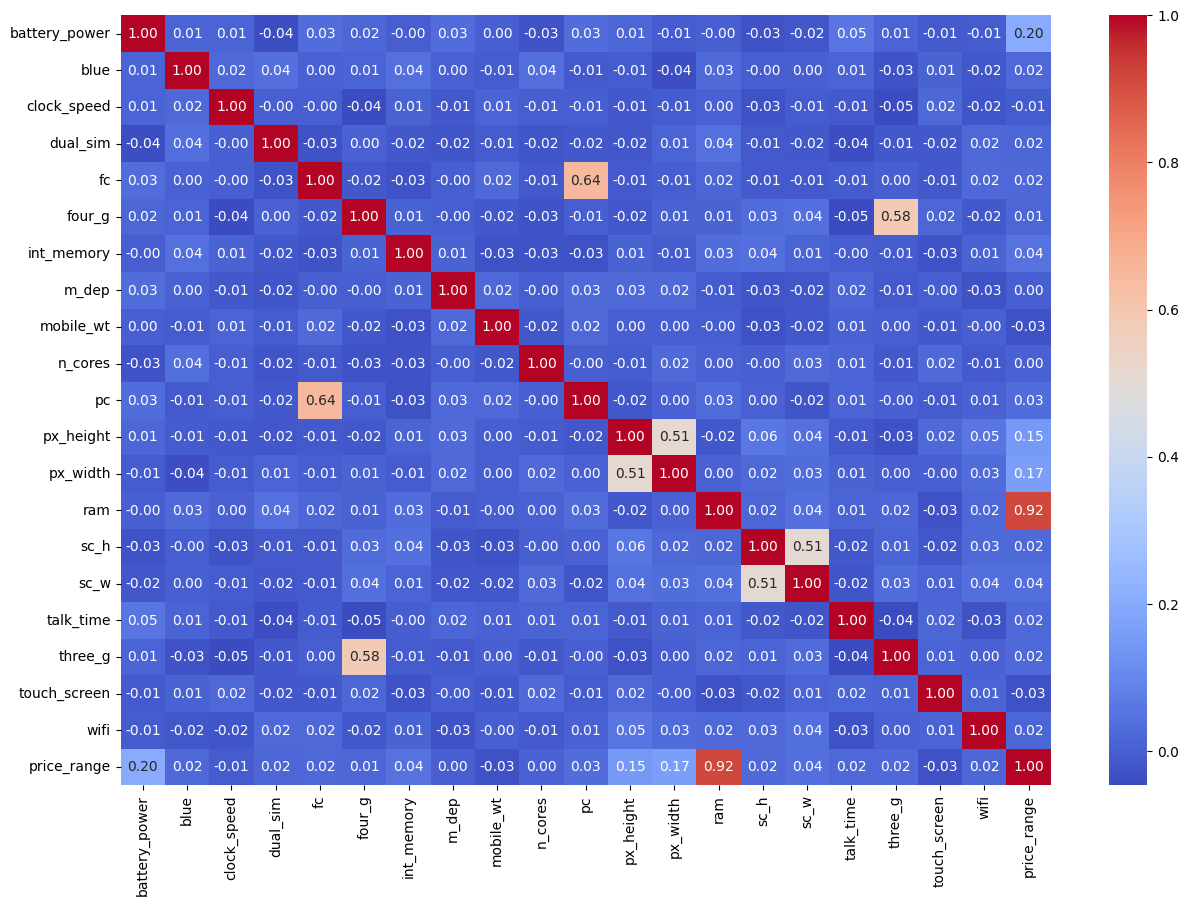

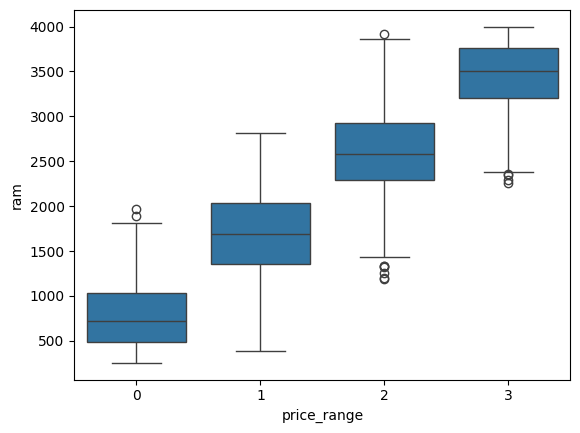

In [12]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(),annot=True,fmt=".2f",cmap='coolwarm')
plt.show()
if 'price_range' in df.columns:
    sns.boxplot(x='price_range',y='ram',data=df)
    plt.show()

In [13]:
df.head(3)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2


In [15]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [16]:
df['price_range'].head(5)

,price_range
0,1
1,2
2,2
3,2
4,1


In [17]:
x = df.drop('price_range',axis=1)

In [18]:
y = df['price_range']

In [19]:
x.shape

(2000, 20)

In [20]:
y.shape

(2000,)

In [21]:
print(df.dtypes)

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object


In [22]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2, random_state=44)

In [23]:
x_train.shape

(1600, 20)

In [24]:
model1 = LogisticRegression()

In [25]:
model2 = RandomForestClassifier()

In [26]:
model1.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [27]:
model2.fit(x_train , y_train)

RandomForestClassifier()

In [28]:
linear_pred = model1.predict(x_test)

In [29]:
random_pred = model2.predict(x_test)

In [30]:
print('linear_prediction \n', confusion_matrix(y_test, linear_pred))

linear_prediction 
 [[81 25  0  0]
 [17 53 21  8]
 [ 1 29 47 22]
 [ 0  2 27 67]]


In [31]:
print('random_prediction \n', confusion_matrix( y_test,random_pred))

random_prediction 
 [[103   3   0   0]
 [  7  82  10   0]
 [  0  15  76   8]
 [  0   0   3  93]]


In [32]:
print('linear_prediction_accuracy)score:? \n', accuracy_score(y_test, linear_pred))

linear_prediction_accuracy)score:? 
 0.62


In [33]:
print('random_prediction_accuracy_score \n', accuracy_score( y_test,random_pred))

random_prediction_accuracy_score 
 0.885


In [34]:
import plotly.express as px

In [40]:
fig = px.scatter_3d(df,
                    x = 'ram',
                    y = 'battery_power',
                    z = 'clock_speed',
                    color='price_range')

fig.show()

/tmp/ipykernel_720/3398962345.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


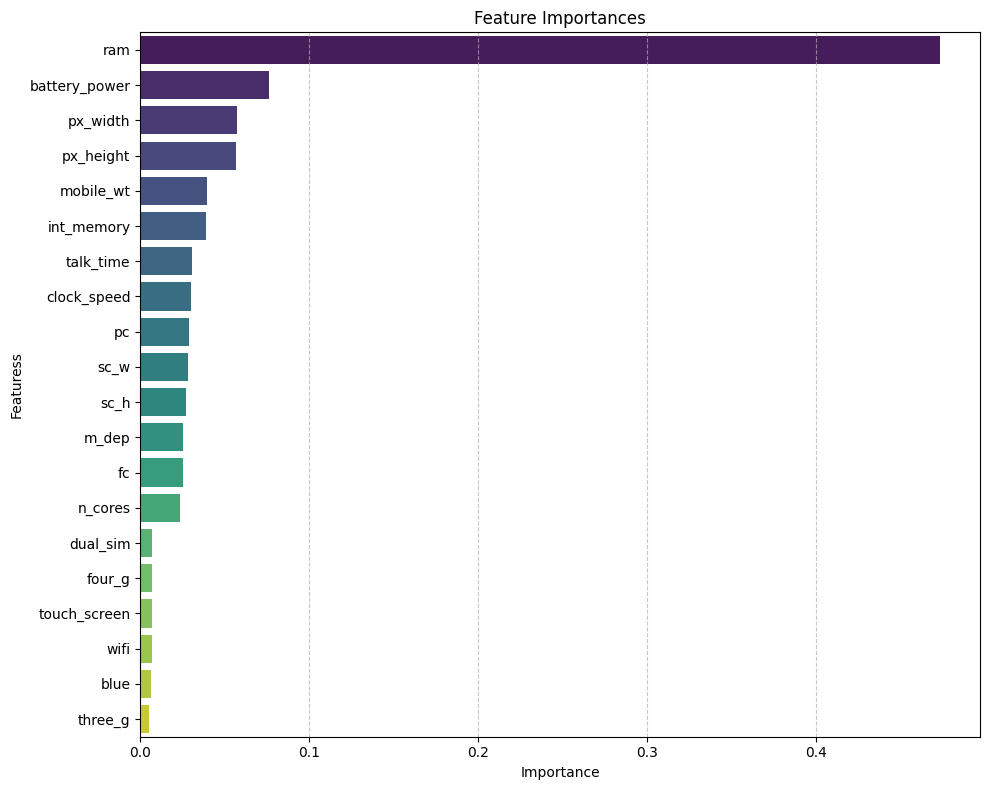

In [36]:


importances = model2.feature_importances_

feature_names = x_train.columns
forest_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=forest_importances,
    palette='viridis')
plt.title('Feature Importances')
plt.ylabel('Featuress')
plt.grid(axis='x', linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()